Попробуем +- по памяти снова сделать модель, надо довести до автоматизма

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
!unzip /content/drive/MyDrive/kaggle_datasets/home-data-for-ml-course.zip

Archive:  /content/drive/MyDrive/kaggle_datasets/home-data-for-ml-course.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: sample_submission.csv.gz  
  inflating: test.csv                
  inflating: test.csv.gz             
  inflating: train.csv               
  inflating: train.csv.gz            


In [ ]:
dataset = pd.read_csv('train.csv', index_col='Id')

In [ ]:
dataset.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
dataset.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [ ]:
dataset_processed = dataset.select_dtypes(exclude=['object'])#.dropna()
dataset_processed = dataset_processed.dropna()
dataset_processed.shape

(1121, 37)

In [ ]:
# print(dataset.columns)
X = dataset_processed.drop(['SalePrice'], axis=1)
y = dataset_processed['SalePrice']

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=2025)

In [ ]:
model_params = []

In [ ]:
model = DecisionTreeRegressor(max_depth=8, random_state=2025)
# model = DecisionTreeRegressor()

In [ ]:
model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, random_state=2025)

In [ ]:
pred = model.predict(X_valid)

In [ ]:
print(f'RMSE for model: {root_mean_squared_error(pred, y_valid)}')

RMSE for model: 41013.09316703576


Теперь добавим поиск оптимальных параметров

In [ ]:
dataset.shape

(1460, 80)

In [ ]:
X.shape

(1121, 36)

In [ ]:
import seaborn as sns

<Axes: >

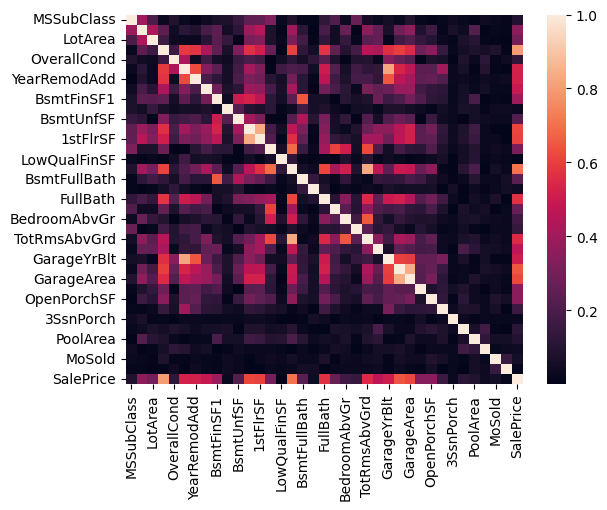

In [ ]:
sns.heatmap(dataset_processed.corr().abs())

In [ ]:
dataset_processed.corr().abs()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,0.386940,0.198096,0.029522,0.087859,0.025800,0.006645,0.040240,0.070389,0.075439,...,0.017988,0.004054,0.017790,0.039739,0.021789,0.003166,0.040689,0.027170,0.012448,0.088032
LotFrontage,0.386940,1.000000,0.421184,0.241322,0.046312,0.109726,0.086414,0.189969,0.241352,0.049305,...,0.082166,0.161815,0.014261,0.069716,0.035906,0.211746,0.001471,0.018815,0.013267,0.344270
LotArea,0.198096,0.421184,1.000000,0.167525,0.034348,0.029205,0.026848,0.106115,0.230441,0.138234,...,0.133576,0.099170,0.023631,0.012520,0.072517,0.109147,0.012790,0.008998,0.006904,0.299962
OverallQual,0.029522,0.241322,0.167525,1.000000,0.163157,0.589385,0.570757,0.423988,0.249500,0.068506,...,0.282512,0.340679,0.144344,0.017331,0.055296,0.080131,0.062064,0.079895,0.008903,0.797881
OverallCond,0.087859,0.046312,0.034348,0.163157,1.000000,0.426462,0.039402,0.166762,0.054788,0.042314,...,0.010835,0.076273,0.062748,0.006861,0.087030,0.023566,0.119772,0.014236,0.041003,0.124391
YearBuilt,0.025800,0.109726,0.029205,0.589385,0.426462,1.000000,0.623171,0.332190,0.236941,0.054414,...,0.238548,0.235432,0.392693,0.027948,0.063694,0.006717,0.096973,0.013784,0.004585,0.525394
YearRemodAdd,0.006645,0.086414,0.026848,0.570757,0.039402,0.623171,1.000000,0.193376,0.120774,0.057024,...,0.244602,0.260521,0.214115,0.026304,0.034288,0.019307,0.040420,0.026884,0.041302,0.521253
MasVnrArea,0.040240,0.189969,0.106115,0.423988,0.166762,0.332190,0.193376,1.000000,0.285331,0.075261,...,0.174649,0.129532,0.116832,0.022331,0.052646,0.021648,0.054044,0.015850,0.017569,0.488658
BsmtFinSF1,0.070389,0.241352,0.230441,0.249500,0.054788,0.236941,0.120774,0.285331,1.000000,0.035780,...,0.206246,0.127900,0.105410,0.021831,0.059635,0.194349,0.003027,0.015281,0.010224,0.390301
BsmtFinSF2,0.075439,0.049305,0.138234,0.068506,0.042314,0.054414,0.057024,0.075261,0.035780,1.000000,...,0.032338,0.010518,0.047221,0.030848,0.067899,0.061212,0.014290,0.036101,0.036395,0.028021


In [ ]:
corr_series = pd.Series(dataset_processed.corr()['SalePrice'])

In [ ]:
print(corr_series.sort_values(ascending=False))

SalePrice        1.000000
OverallQual      0.797881
GrLivArea        0.705154
GarageCars       0.647034
GarageArea       0.619330
TotalBsmtSF      0.615612
1stFlrSF         0.607969
FullBath         0.566627
TotRmsAbvGrd     0.547067
YearBuilt        0.525394
YearRemodAdd     0.521253
GarageYrBlt      0.504753
MasVnrArea       0.488658
Fireplaces       0.461873
BsmtFinSF1       0.390301
LotFrontage      0.344270
OpenPorchSF      0.343354
WoodDeckSF       0.336855
2ndFlrSF         0.306879
LotArea          0.299962
HalfBath         0.268560
BsmtFullBath     0.236737
BsmtUnfSF        0.213129
BedroomAbvGr     0.166814
ScreenPorch      0.110427
PoolArea         0.092488
MoSold           0.051568
3SsnPorch        0.030777
LowQualFinSF    -0.001482
YrSold          -0.011869
BsmtFinSF2      -0.028021
MiscVal         -0.036041
BsmtHalfBath    -0.036513
MSSubClass      -0.088032
OverallCond     -0.124391
KitchenAbvGr    -0.140497
EnclosedPorch   -0.154843
Name: SalePrice, dtype: float64


In [ ]:
# good_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', '1stFlrSF', 'FullBath', 'TotalBsmtSF']
good_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', '1stFlrSF', 'FullBath', 'TotalBsmtSF']

In [ ]:
X_good = X[good_features]

In [ ]:
X_good_train, X_good_valid, y_good_train, y_good_valid = train_test_split(X_good, y, random_state=2025)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {'max_depth' : [5,8,10,12,15,20],
              'min_samples_split' : [2, 5, 10, 15, 20, 25, 30],
              'min_samples_leaf' : [1, 2, 4, 6, 10]}

In [ ]:
model2 = DecisionTreeRegressor()

In [ ]:
optimizer = GridSearchCV(estimator = model2, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error')
# optimizer = GridSearchCV(estimator = model2, param_grid=param_grid, cv=5, scoring='neg_root_mean_squared_error')

In [ ]:
optimizer.fit(X_good_train, y_good_train)
# optimizer.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [5, 8, 10, 12, 15, 20],
                         'min_samples_leaf': [1, 2, 4, 6, 10],
                         'min_samples_split': [2, 5, 10, 15, 20, 25, 30]},
             scoring='neg_mean_absolute_error')

In [ ]:
print(optimizer.best_params_, optimizer.best_score_)

{'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 2} -24664.13954339296


In [ ]:
best_model = optimizer.best_estimator_
pred = best_model.predict(X_good_valid)
print(f'RMSE for model: {mean_absolute_error(pred, y_good_valid)}')
# print(f'RMSE for model: {root_mean_squared_error(pred, y_good_valid)}')
# pred = best_model.predict(X_valid)
# print(f'RMSE for model: {root_mean_squared_error(pred, y_valid)}')

RMSE for model: 28037.301475192653


Слабая модель, попробуем другую

In [ ]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
model3 = RandomForestRegressor()
param_grid2 = {'n_estimators' : [10,50,100],
               'max_depth' : [5,10,12,15,20],
               'min_samples_split' : [2, 5, 10, 20, 30],
               'min_samples_leaf' : [1, 5, 10]}
optimizer2 = GridSearchCV(estimator = model3, param_grid=param_grid2, cv=5, scoring='neg_mean_absolute_error')
# optimizer2 = GridSearchCV(estimator = model3, param_grid=param_grid2, cv=5, scoring='neg_root_mean_squared_error')

In [ ]:
optimizer2.fit(X_good_train, y_good_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [5, 10, 12, 15, 20],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 5, 10, 20, 30],
                         'n_estimators': [10, 50, 100]},
             scoring='neg_mean_absolute_error')

In [ ]:
best_model2 = optimizer2.best_estimator_
pred = best_model2.predict(X_good_valid)
print(f'RMSE for model: {mean_absolute_error(pred, y_good_valid)}')

RMSE for model: 24525.504864837232
